# General Fallback MIL — All MURA Bone Types

Multi-task Attention-MIL model trained on all 8 MURA bone types.  
Used as fallback when the bone classifier returns an unknown bone type.

**Two output heads:**
- Binary: Normal vs Abnormal (sigmoid)
- Multi-class: Bone type prediction (8-class softmax)

**Dataset structure expected:**
```
/kaggle/input/<your-dataset-name>/
    MURA-v1.1/
        train/
            XR_ELBOW/   XR_FINGER/  XR_FOREARM/
            XR_HAND/    XR_HUMERUS/ XR_SHOULDER/
            XR_WRIST/   XR_FINGER/
                patient00001/
                    study1_positive/  *.png
                    study1_negative/  *.png
        valid/
            (same structure)
```

## 1. Imports

In [1]:
import os
import csv
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from tqdm import tqdm
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

print("PyTorch :", torch.__version__)
print("CUDA    :", torch.cuda.is_available())

PyTorch : 2.10.0+cu128
CUDA    : True


## 2. Paths & bone type mapping

> Update `DATA_ROOT` to point to your Kaggle dataset containing the full MURA-v1.1 folder.

In [2]:
DATA_ROOT      = "/kaggle/input/datasets/nadabhm/muradata/MURA-v1.1"
CHECKPOINT_DIR = "/kaggle/working/checkpoints_general"
BEST_MODEL_PATH = f"/kaggle/working/best_model_general.pth"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

TRAIN_CSV = "/kaggle/working/general_train.csv"
VALID_CSV = "/kaggle/working/general_valid.csv"

# All 8 MURA bone types — order defines the class index for bone head
BONE_TYPES = [
    "XR_ELBOW",
    "XR_FINGER",
    "XR_FOREARM",
    "XR_HAND",
    "XR_HUMERUS",
    "XR_SHOULDER",
    "XR_WRIST",
    "XR_FINGER",  
]
# Deduplicate while preserving order
seen = set()
BONE_TYPES = [b for b in BONE_TYPES if not (b in seen or seen.add(b))]
NUM_BONE_CLASSES = len(BONE_TYPES)
BONE2IDX = {b: i for i, b in enumerate(BONE_TYPES)}

print("DATA_ROOT:", DATA_ROOT)
print("Exists?  ", os.path.exists(DATA_ROOT))
print(f"Bone types ({NUM_BONE_CLASSES}):", BONE_TYPES)

# Detect structure per-split independently (handles flat and double-nested layouts)
def get_bone_base(split, bone_type):
    candidates = [
        os.path.join(DATA_ROOT, split, bone_type),
        os.path.join(DATA_ROOT, split, split, bone_type),
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
    # fallback: walk
    split_root = os.path.join(DATA_ROOT, split)
    for root, dirs, _ in os.walk(split_root):
        if os.path.basename(root) == bone_type:
            return root
    return None

# Verify all bone types exist
for split in ["train", "valid"]:
    print(f"\n{split}:")
    for bt in BONE_TYPES:
        base = get_bone_base(split, bt)
        status = "OK" if base else "MISSING"
        print(f"  [{status}] {bt}")

DATA_ROOT: /kaggle/input/datasets/nadabhm/muradata/MURA-v1.1
Exists?   True
Bone types (7): ['XR_ELBOW', 'XR_FINGER', 'XR_FOREARM', 'XR_HAND', 'XR_HUMERUS', 'XR_SHOULDER', 'XR_WRIST']

train:
  [OK] XR_ELBOW
  [OK] XR_FINGER
  [OK] XR_FOREARM
  [OK] XR_HAND
  [OK] XR_HUMERUS
  [OK] XR_SHOULDER
  [OK] XR_WRIST

valid:
  [OK] XR_ELBOW
  [OK] XR_FINGER
  [OK] XR_FOREARM
  [OK] XR_HAND
  [OK] XR_HUMERUS
  [OK] XR_SHOULDER
  [OK] XR_WRIST


## 3. Explore dataset structure

In [3]:
for split in ["train", "valid"]:
    print(f"\n{'='*40}")
    print(f"{split.upper()}")
    total = 0
    for bt in BONE_TYPES:
        base = get_bone_base(split, bt)
        if not base:
            print(f"  {bt}: MISSING")
            continue
        patients = [p for p in os.listdir(base) if os.path.isdir(os.path.join(base, p))]
        n_studies = sum(
            len([s for s in os.listdir(os.path.join(base, p))
                 if os.path.isdir(os.path.join(base, p, s))])
            for p in patients
        )
        total += n_studies
        print(f"  {bt}: {len(patients)} patients, {n_studies} studies")
    print(f"  TOTAL: {total} studies")


TRAIN
  XR_ELBOW: 1711 patients, 1754 studies
  XR_FINGER: 1865 patients, 1935 studies
  XR_FOREARM: 865 patients, 877 studies
  XR_HAND: 1945 patients, 2018 studies
  XR_HUMERUS: 587 patients, 592 studies
  XR_SHOULDER: 2694 patients, 2821 studies
  XR_WRIST: 3267 patients, 3460 studies
  TOTAL: 13457 studies

VALID
  XR_ELBOW: 152 patients, 158 studies
  XR_FINGER: 166 patients, 175 studies
  XR_FOREARM: 129 patients, 133 studies
  XR_HAND: 159 patients, 167 studies
  XR_HUMERUS: 132 patients, 135 studies
  XR_SHOULDER: 173 patients, 194 studies
  XR_WRIST: 207 patients, 237 studies
  TOTAL: 1199 studies


## 4. Build CSV manifests

In [4]:
def build_csv_all_bones(split, out_csv):
    """
    Builds CSV with columns: study_path, abnormal_label, bone_label
    study_path encodes both split and bone type so __getitem__ can resolve it.
    """
    rows = []
    for bt in BONE_TYPES:
        base = get_bone_base(split, bt)
        if not base:
            print(f"  [SKIP] {bt} not found for {split}")
            continue
        bone_label = BONE2IDX[bt]
        for patient in sorted(os.listdir(base)):
            patient_dir = os.path.join(base, patient)
            if not os.path.isdir(patient_dir):
                continue
            for study in sorted(os.listdir(patient_dir)):
                study_dir = os.path.join(patient_dir, study)
                if not os.path.isdir(study_dir):
                    continue
                if "positive" in study.lower():
                    abnormal_label = 1
                elif "negative" in study.lower():
                    abnormal_label = 0
                else:
                    print(f"  [SKIP] No label in study name: {study}")
                    continue
                # Store path relative to DATA_ROOT so it survives across machines
                rows.append([
                    f"{split}/{bt}/{patient}/{study}",
                    abnormal_label,
                    bone_label
                ])

    with open(out_csv, "w", newline="") as f:
        csv.writer(f).writerows(rows)
    print(f"{split}: {len(rows)} studies → {out_csv}")
    return len(rows)

build_csv_all_bones("train", TRAIN_CSV)
build_csv_all_bones("valid", VALID_CSV)

train: 13457 studies → /kaggle/working/general_train.csv
valid: 1199 studies → /kaggle/working/general_valid.csv


1199

## 5. Rebalance validation set

If valid is heavily skewed toward Abnormal, move some Normal studies from train.  
This is done per bone type to keep all types represented.

In [5]:
train_df = pd.read_csv(TRAIN_CSV, header=None, names=["study_path", "abnormal", "bone"])
valid_df = pd.read_csv(VALID_CSV, header=None, names=["study_path", "abnormal", "bone"])

print("Before rebalancing:")
print("  Train abnormal distribution:", train_df.abnormal.value_counts().to_dict())
print("  Valid abnormal distribution:", valid_df.abnormal.value_counts().to_dict())

# Move up to N_MOVE Normal studies per bone type from train → valid
N_MOVE_PER_BONE = 8
to_move = []

for bone_idx in range(NUM_BONE_CLASSES):
    train_normal_bone = train_df[
        (train_df.bone == bone_idx) & (train_df.abnormal == 0)
    ]
    n = min(N_MOVE_PER_BONE, len(train_normal_bone))
    if n > 0:
        to_move.append(train_normal_bone.sample(n=n, random_state=42))

if to_move:
    moved = pd.concat(to_move)
    train_df = train_df.drop(moved.index).reset_index(drop=True)
    valid_df = pd.concat([valid_df, moved], ignore_index=True).sample(
        frac=1, random_state=42
    ).reset_index(drop=True)

train_df.to_csv(TRAIN_CSV, header=False, index=False)
valid_df.to_csv(VALID_CSV, header=False, index=False)

print("\nAfter rebalancing:")
print("  Train:", train_df.abnormal.value_counts().to_dict(), "| total:", len(train_df))
print("  Valid:", valid_df.abnormal.value_counts().to_dict(), "| total:", len(valid_df))

Before rebalancing:
  Train abnormal distribution: {0: 8280, 1: 5177}
  Valid abnormal distribution: {0: 661, 1: 538}

After rebalancing:
  Train: {0: 8224, 1: 5177} | total: 13401
  Valid: {0: 717, 1: 538} | total: 1255


## 6. Class distribution

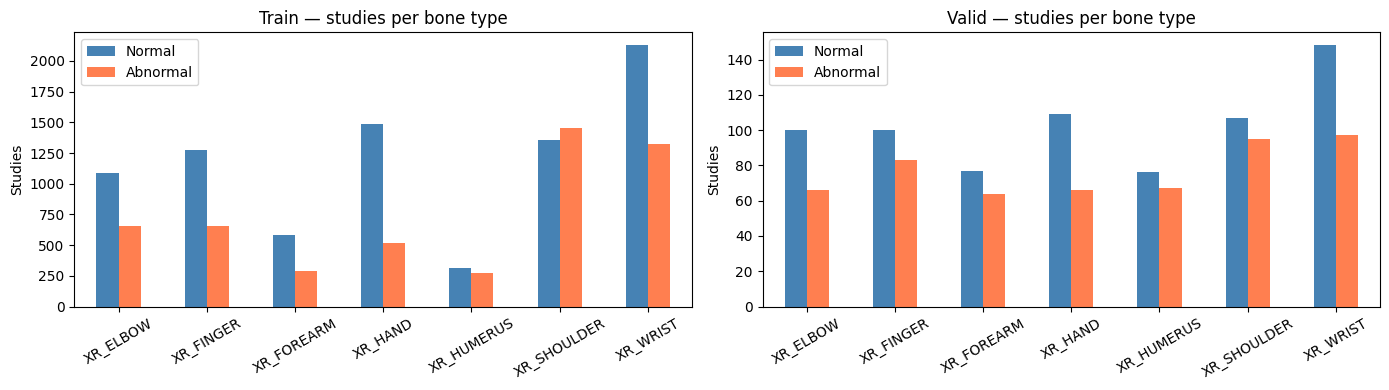


Train bone distribution:
  XR_ELBOW: 1746 studies  (N=1086, Ab=660)
  XR_FINGER: 1927 studies  (N=1272, Ab=655)
  XR_FOREARM: 869 studies  (N=582, Ab=287)
  XR_HAND: 2010 studies  (N=1489, Ab=521)
  XR_HUMERUS: 584 studies  (N=313, Ab=271)
  XR_SHOULDER: 2813 studies  (N=1356, Ab=1457)
  XR_WRIST: 3452 studies  (N=2126, Ab=1326)

Valid bone distribution:
  XR_ELBOW: 166 studies  (N=100, Ab=66)
  XR_FINGER: 183 studies  (N=100, Ab=83)
  XR_FOREARM: 141 studies  (N=77, Ab=64)
  XR_HAND: 175 studies  (N=109, Ab=66)
  XR_HUMERUS: 143 studies  (N=76, Ab=67)
  XR_SHOULDER: 202 studies  (N=107, Ab=95)
  XR_WRIST: 245 studies  (N=148, Ab=97)


In [6]:
train_df = pd.read_csv(TRAIN_CSV, header=None, names=["study_path", "abnormal", "bone"])
valid_df = pd.read_csv(VALID_CSV, header=None, names=["study_path", "abnormal", "bone"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Abnormal distribution
for ax, df, title in zip(axes, [train_df, valid_df], ["Train", "Valid"]):
    counts = df.groupby(["bone", "abnormal"]).size().unstack(fill_value=0)
    counts.index = [BONE_TYPES[i] for i in counts.index]
    counts.columns = ["Normal", "Abnormal"]
    counts.plot(kind="bar", ax=ax, color=["steelblue", "coral"])
    ax.set_title(f"{title} — studies per bone type")
    ax.set_ylabel("Studies")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print("\nTrain bone distribution:")
for i, bt in enumerate(BONE_TYPES):
    sub = train_df[train_df.bone == i]
    print(f"  {bt}: {len(sub)} studies  (N={( sub.abnormal==0).sum()}, Ab={(sub.abnormal==1).sum()})")

print("\nValid bone distribution:")
for i, bt in enumerate(BONE_TYPES):
    sub = valid_df[valid_df.bone == i]
    print(f"  {bt}: {len(sub)} studies  (N={(sub.abnormal==0).sum()}, Ab={(sub.abnormal==1).sum()})")

## 7. Preprocessing helpers

Anatomy-agnostic: bone windowing + CLAHE only.  
No Frangi filter — the general model must handle unknown bone types.

In [7]:
def bone_window(img):
    """Percentile-based contrast stretching"""
    img = img.astype(np.float32)
    p1, p99 = np.percentile(img, (0.5, 99.5))
    img = np.clip(img, p1, p99)
    if p99 - p1 > 0:
        img = (img - p1) / (p99 - p1)
    return img

def apply_clahe(img_float):
    """CLAHE on a [0,1] float image, returns uint8"""
    img8 = (img_float * 255).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(img8)   # uint8 [0-255]

def preprocess_xray(img_path):
    """Load, window, CLAHE. Returns uint8 grayscale or None."""
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None or img.shape[0] < 50 or img.shape[1] < 50:
        return None
    img = bone_window(img)
    img = apply_clahe(img)
    return img   # uint8

print("Preprocessing helpers defined.")

Preprocessing helpers defined.


## 8. Multi-task MIL Dataset

In [8]:
class MuraGeneralMIL(Dataset):
    """
    Study-level MIL dataset for all MURA bone types.

    CSV columns: study_path, abnormal_label, bone_label
    study_path format: split/BONE_TYPE/patient/study
    """
    def __init__(self, csv_file, transform=None):
        self.df = pd.read_csv(
            csv_file, header=None,
            names=["study_path", "abnormal", "bone"]
        ).reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        abnormal_label = torch.tensor(row.abnormal, dtype=torch.float32)
        bone_label     = torch.tensor(row.bone,     dtype=torch.long)

        # study_path: "train/XR_HAND/patient00001/study1_positive"
        parts      = row.study_path.split("/", 2)   # [split, bone_type, patient/study]
        split      = parts[0]                        # "train" or "valid"
        bone_type  = parts[1]                        # "XR_HAND" etc.
        rest       = parts[2]                        # "patient00001/study1_positive"

        base      = get_bone_base(split, bone_type)
        study_dir = os.path.join(base, rest)

        images = []
        for fname in sorted(os.listdir(study_dir)):
            if not fname.lower().endswith(".png"):
                continue
            img_path = os.path.join(study_dir, fname)
            img = preprocess_xray(img_path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            if self.transform:
                img = self.transform(img)
            images.append(img)

        if len(images) == 0:
            # Fallback: blank image so the batch doesn't crash
            dummy = torch.zeros(3, 224, 224)
            return dummy.unsqueeze(0), abnormal_label, bone_label

        return torch.stack(images), abnormal_label, bone_label   # [N, 3, 224, 224]

## 9. Transforms

In [9]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(5),
    T.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
    T.RandomAutocontrast(p=0.3),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tf = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

## 10. DataLoaders & class weighting

In [10]:
train_ds = MuraGeneralMIL(TRAIN_CSV, train_tf)
valid_ds = MuraGeneralMIL(VALID_CSV, val_tf)

# Weight sampler on abnormal label to handle imbalance
abnormal_labels    = train_ds.df["abnormal"].values
class_sample_count = np.array([(abnormal_labels == 0).sum(), (abnormal_labels == 1).sum()])
weight             = 1.0 / class_sample_count
samples_weight     = torch.from_numpy(
    np.array([weight[t] for t in abnormal_labels])
).double()
sampler = WeightedRandomSampler(samples_weight, len(samples_weight), replacement=True)

train_loader = DataLoader(train_ds, batch_size=1, sampler=sampler,  num_workers=2)
val_loader   = DataLoader(valid_ds, batch_size=1, shuffle=False,    num_workers=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

pos        = int((abnormal_labels == 1).sum())
neg        = int((abnormal_labels == 0).sum())
pos_weight = torch.tensor([neg / pos], dtype=torch.float32).to(device)

# Loss functions
criterion_abnormal = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
criterion_bone     = nn.CrossEntropyLoss()   # bone type head

# Weight of each task in the combined loss (tune if one task dominates)
LAMBDA_ABNORMAL = 1.0
LAMBDA_BONE     = 0.4

print(f"Train bags : {len(train_ds)}  |  Valid bags : {len(valid_ds)}")
print(f"Normal: {neg}  |  Abnormal: {pos}  |  pos_weight: {pos_weight.item():.4f}")
print(f"Device: {device}")

Train bags : 13401  |  Valid bags : 1255
Normal: 8224  |  Abnormal: 5177  |  pos_weight: 1.5886
Device: cuda


## 11. Multi-task Attention-MIL model (MobileNetV2 backbone)

Shared MobileNetV2 backbone → attention pooling → two heads:
- `classifier_abnormal`: Normal vs Abnormal (binary)
- `classifier_bone`: bone type (8-class)

In [11]:
class MultiTaskAttentionMIL(nn.Module):
    def __init__(self, num_bone_classes):
        super().__init__()
        backbone               = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        self.feature_extractor = backbone.features
        self.pool              = nn.AdaptiveAvgPool2d(1)
        self.feat_dim          = 1280
        self.dropout           = nn.Dropout(0.3)

        # Shared attention mechanism
        self.attention = nn.Sequential(
            nn.Linear(self.feat_dim, 256),
            nn.Tanh(),
            nn.Linear(256, 1),
        )

        # Head 1: Normal vs Abnormal
        self.classifier_abnormal = nn.Linear(self.feat_dim, 1)

        # Head 2: Bone type (uses the same bag representation)
        self.classifier_bone = nn.Sequential(
            nn.Linear(self.feat_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_bone_classes),
        )

    def forward(self, x):            # x: [1, N, 3, H, W]
        x     = x.squeeze(0)         # [N, 3, H, W]
        feats = self.feature_extractor(x)
        feats = self.pool(feats).view(feats.size(0), -1)   # [N, 1280]

        A   = torch.softmax(self.attention(feats), dim=0)  # [N, 1]
        bag = self.dropout(torch.sum(A * feats, dim=0))    # [1280]

        out_abnormal = self.classifier_abnormal(bag)       # scalar logit
        out_bone     = self.classifier_bone(bag)           # [num_bone_classes] logits

        return out_abnormal, out_bone, A

## 12. Training

In [12]:
MAX_BAG_TRAIN = 8
MAX_BAG_VAL   = 12
NUM_EPOCHS    = 25
PATIENCE      = 7

model = MultiTaskAttentionMIL(num_bone_classes=NUM_BONE_CLASSES).to(device)

optimizer = torch.optim.AdamW([
    {'params': model.feature_extractor.parameters(),    'lr': 1e-5},
    {'params': model.attention.parameters(),            'lr': 1e-4},
    {'params': model.classifier_abnormal.parameters(),  'lr': 1e-4},
    {'params': model.classifier_bone.parameters(),      'lr': 1e-4},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# ── Resume if checkpoint exists ──
resume_path = os.path.join(CHECKPOINT_DIR, "last_checkpoint_general.pth")
best_auc    = 0.0
start_epoch = 0
no_improve  = 0

if os.path.exists(resume_path):
    print(f"Resuming from: {resume_path}")
    try:
        ckpt        = torch.load(resume_path, weights_only=False, map_location=device)
        model.load_state_dict(ckpt['model_state_dict'])
        start_epoch = ckpt['epoch'] + 1
        best_auc    = ckpt.get('best_auc', 0.0)
        no_improve  = ckpt.get('no_improve', 0)
        print(f"Epoch {start_epoch}, best_auc={best_auc:.4f}, no_improve={no_improve}")
    except RuntimeError as e:
        print(f"Incompatible checkpoint ({e}). Starting fresh.")
else:
    print("No checkpoint — starting fresh.")

# ── Training loop ──
for epoch in range(start_epoch, NUM_EPOCHS):

    if epoch == 1:
        print("Unfreezing backbone (BN stays frozen)...")
        for p in model.feature_extractor.parameters():
            p.requires_grad = True

    model.train()
    if epoch >= 1:
        for m in model.feature_extractor.modules():
            if isinstance(m, nn.BatchNorm2d):
                m.eval()

    train_loss = 0.0
    for bags, abn_label, bone_label in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]"):
        bags      = bags.to(device)
        abn_label = abn_label.to(device).float()
        bone_label = bone_label.to(device)

        if bags.size(1) > MAX_BAG_TRAIN:
            bags = bags[:, torch.randperm(bags.size(1))[:MAX_BAG_TRAIN]]

        out_abn, out_bone, _ = model(bags)

        loss_abn  = criterion_abnormal(out_abn.view(-1), abn_label.view(-1))
        loss_bone = criterion_bone(out_bone.unsqueeze(0), bone_label)
        loss      = LAMBDA_ABNORMAL * loss_abn + LAMBDA_BONE * loss_bone

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ── Validation ──
    model.eval()
    val_loss       = 0.0
    all_preds      = []
    all_abn_labels = []
    all_bone_preds = []
    all_bone_labels= []

    with torch.no_grad():
        for bags, abn_label, bone_label in tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Valid]"):
            bags      = bags.to(device)
            abn_label = abn_label.to(device).float()
            bone_label = bone_label.to(device)

            if bags.size(1) > MAX_BAG_VAL:
                n = bags.size(1); s = (n - MAX_BAG_VAL) // 2
                bags = bags[:, s:s + MAX_BAG_VAL]

            out_abn, out_bone, _ = model(bags)

            loss_abn  = criterion_abnormal(out_abn.view(-1), abn_label.view(-1))
            loss_bone = criterion_bone(out_bone.unsqueeze(0), bone_label)
            val_loss += (LAMBDA_ABNORMAL * loss_abn + LAMBDA_BONE * loss_bone).item()

            all_preds.append(torch.sigmoid(out_abn).cpu().numpy())
            all_abn_labels.append(abn_label.cpu().numpy())
            all_bone_preds.append(out_bone.argmax().cpu().item())
            all_bone_labels.append(bone_label.cpu().item())

    val_loss   /= len(val_loader)
    all_preds   = np.concatenate(all_preds).ravel()
    all_abn_labels = np.concatenate(all_abn_labels).ravel()
    auc         = roc_auc_score(all_abn_labels, all_preds)
    bone_acc    = np.mean(np.array(all_bone_preds) == np.array(all_bone_labels))

    print(f"\nEpoch {epoch+1}  Train: {train_loss:.4f}  Val: {val_loss:.4f}  "
          f"AUC: {auc:.4f}  BoneAcc: {bone_acc:.4f}")
    scheduler.step()

    ckpt_state = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_auc': best_auc,
        'no_improve': no_improve,
        'bone_types': BONE_TYPES,
        'num_bone_classes': NUM_BONE_CLASSES,
    }
    torch.save(ckpt_state, os.path.join(CHECKPOINT_DIR, "last_checkpoint_general.pth"))

    # update no_improve FIRST
    if auc > best_auc:
        best_auc = auc
        no_improve = 0  # ← reset
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"✅ Best model saved → {BEST_MODEL_PATH}  (AUC={best_auc:.4f})")
    else:
        no_improve += 1
        print(f"  No improvement ({no_improve}/{PATIENCE})")
        if no_improve >= PATIENCE:
            print("Early stopping!"); break

    # THEN save checkpoint with correct no_improve
    ckpt_state = {
        'epoch': epoch, 'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_auc': best_auc, 'no_improve': no_improve,
    }
    torch.save(ckpt_state, os.path.join(CHECKPOINT_DIR, "last_checkpoint_general.pth"))

# After the training loop, force-save if best model file doesn't exist
if not os.path.exists(BEST_MODEL_PATH):
    torch.save(model.state_dict(), BEST_MODEL_PATH)
    print(f"⚠️ Forced save → {BEST_MODEL_PATH}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 108MB/s] 


No checkpoint — starting fresh.


Epoch 1/25 [Valid]: 100%|██████████| 1255/1255 [00:51<00:00, 24.26it/s]



Epoch 1  Train: 1.1724  Val: 2.3129  AUC: 0.5156  BoneAcc: 0.3514
✅ Best model saved → /kaggle/working/best_model_general.pth  (AUC=0.5156)
Unfreezing backbone (BN stays frozen)...


...


Epoch 13  Train: 0.3337  Val: 0.7221  AUC: 0.8717  BoneAcc: 0.9737
  No improvement (5/7)


Epoch 14/25 [Valid]: 100%|██████████| 1255/1255 [00:35<00:00, 35.52it/s]



Epoch 14  Train: 0.3102  Val: 0.8549  AUC: 0.8628  BoneAcc: 0.9745
  No improvement (6/7)


Epoch 15/25 [Valid]: 100%|██████████| 1255/1255 [00:33<00:00, 37.04it/s]



Epoch 15  Train: 0.2775  Val: 0.8162  AUC: 0.8567  BoneAcc: 0.9745
  No improvement (7/7)
Early stopping!


## 13. Evaluation — Abnormality head

Best model loaded (raw state_dict — no epoch/AUC metadata available)


Inference: 100%|██████████| 1255/1255 [00:34<00:00, 36.88it/s]



Validation set: 717 Normal / 538 Abnormal
AUC: 0.8837  |  F1-optimal threshold: 0.4185


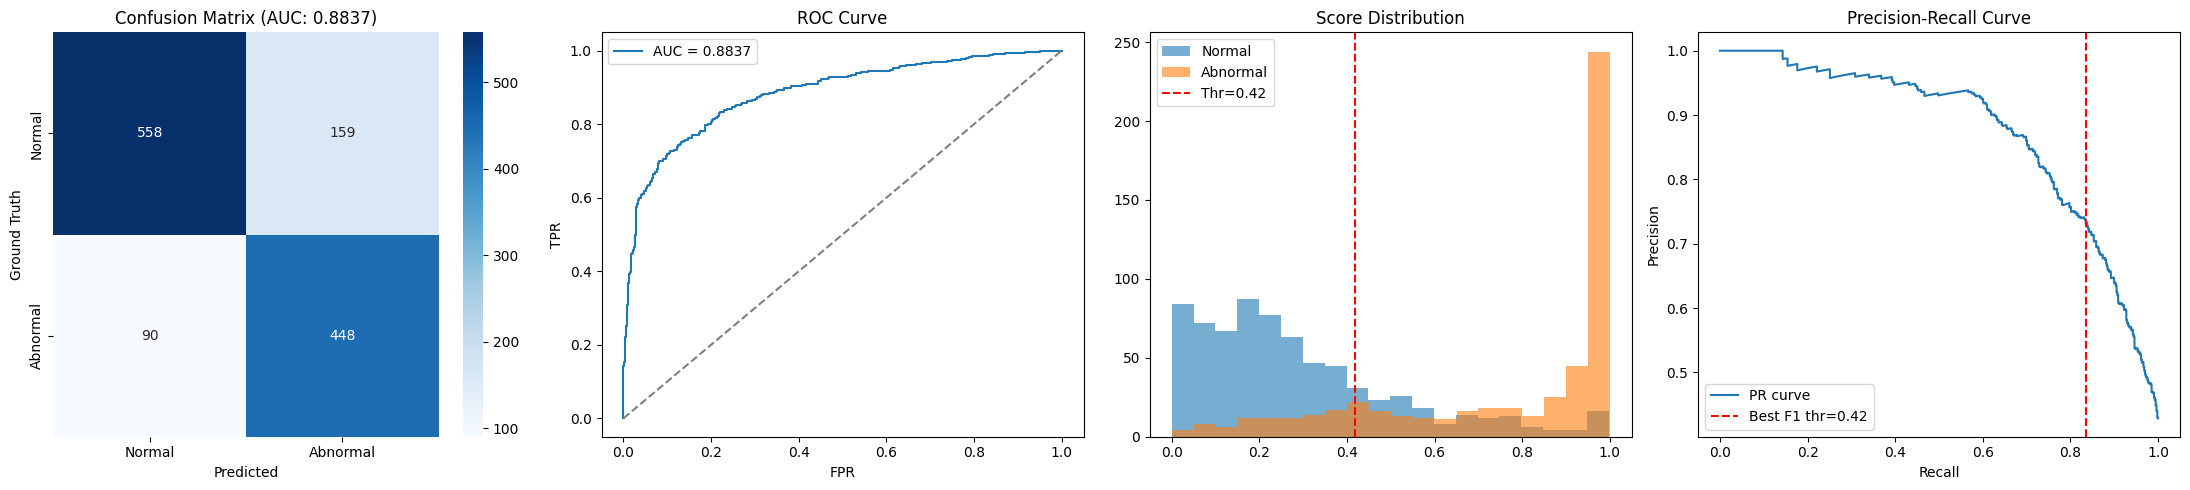

Accuracy    : 0.8016
Precision   : 0.7381
Recall      : 0.8327
Specificity : 0.7782
F1 Score    : 0.7825
              precision    recall  f1-score   support

      Normal       0.86      0.78      0.82       717
    Abnormal       0.74      0.83      0.78       538

    accuracy                           0.80      1255
   macro avg       0.80      0.81      0.80      1255
weighted avg       0.81      0.80      0.80      1255



In [14]:
best_path = BEST_MODEL_PATH
if os.path.exists(best_path):
    ckpt = torch.load(best_path, map_location=device, weights_only=False)
    
    # Best model is saved as a raw state_dict, not a checkpoint dict
    if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
        model.load_state_dict(ckpt['model_state_dict'])
        print(f"Best model: epoch {ckpt['epoch']+1}, AUC {ckpt['best_auc']:.4f}")
    else:
        # Raw state_dict (saved via torch.save(model.state_dict(), ...))
        model.load_state_dict(ckpt)
        print("Best model loaded (raw state_dict — no epoch/AUC metadata available)")
else:
    print("[WARNING] best_model_general.pth not found — using current model state.")

model.eval()
all_preds       = []
all_abn_labels  = []
all_bone_preds  = []
all_bone_labels = []

with torch.no_grad():
    for bags, abn_label, bone_label in tqdm(val_loader, desc="Inference"):
        bags = bags.to(device)
        out_abn, out_bone, _ = model(bags)
        all_preds.append(torch.sigmoid(out_abn).cpu().numpy())
        all_abn_labels.append(abn_label.numpy())
        all_bone_preds.append(out_bone.argmax().cpu().item())
        all_bone_labels.append(bone_label.item())

all_preds      = np.concatenate(all_preds).ravel()
all_abn_labels = np.concatenate(all_abn_labels).ravel()

print(f"\nValidation set: {int((all_abn_labels==0).sum())} Normal / "
      f"{int((all_abn_labels==1).sum())} Abnormal")

# AUC + thresholds
auc_score     = roc_auc_score(all_abn_labels, all_preds)
fpr, tpr, thr = roc_curve(all_abn_labels, all_preds)

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(all_abn_labels, all_preds)
f1_scores = 2 * precision_vals * recall_vals / (precision_vals + recall_vals + 1e-8)
best_thr  = pr_thresholds[np.argmax(f1_scores[:-1])]

binary_preds = (all_preds > best_thr).astype(int)
print(f"AUC: {auc_score:.4f}  |  F1-optimal threshold: {best_thr:.4f}")

# Confusion matrix
cm = confusion_matrix(all_abn_labels, binary_preds)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Abnormal'],
            yticklabels=['Normal', 'Abnormal'])
axes[0].set_title(f'Confusion Matrix (AUC: {auc_score:.4f})')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Ground Truth')

axes[1].plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
axes[1].plot([0,1],[0,1],'--', color='grey')
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("ROC Curve"); axes[1].legend()

axes[2].hist(all_preds[all_abn_labels==0], bins=20, alpha=0.6, label='Normal')
axes[2].hist(all_preds[all_abn_labels==1], bins=20, alpha=0.6, label='Abnormal')
axes[2].axvline(best_thr, color='red', linestyle='--', label=f'Thr={best_thr:.2f}')
axes[2].set_title("Score Distribution"); axes[2].legend()

axes[3].plot(recall_vals, precision_vals, label='PR curve')
axes[3].axvline(recall_vals[np.argmax(f1_scores[:-1])], color='red', linestyle='--',
                label=f'Best F1 thr={best_thr:.2f}')
axes[3].set_xlabel("Recall"); axes[3].set_ylabel("Precision")
axes[3].set_title("Precision-Recall Curve"); axes[3].legend()

plt.tight_layout(); plt.show()

accuracy    = (tp+tn)/(tp+tn+fp+fn)
precision   = tp/(tp+fp)  if (tp+fp)>0 else 0
recall      = tp/(tp+fn)  if (tp+fn)>0 else 0
specificity = tn/(tn+fp)  if (tn+fp)>0 else 0
f1          = 2*(precision*recall)/(precision+recall) if (precision+recall)>0 else 0

print("=" * 40)
print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F1 Score    : {f1:.4f}")
print("=" * 40)
print(classification_report(all_abn_labels, binary_preds, target_names=['Normal','Abnormal']))

## 14. Evaluation — Bone type head

Bone type accuracy: 0.9745


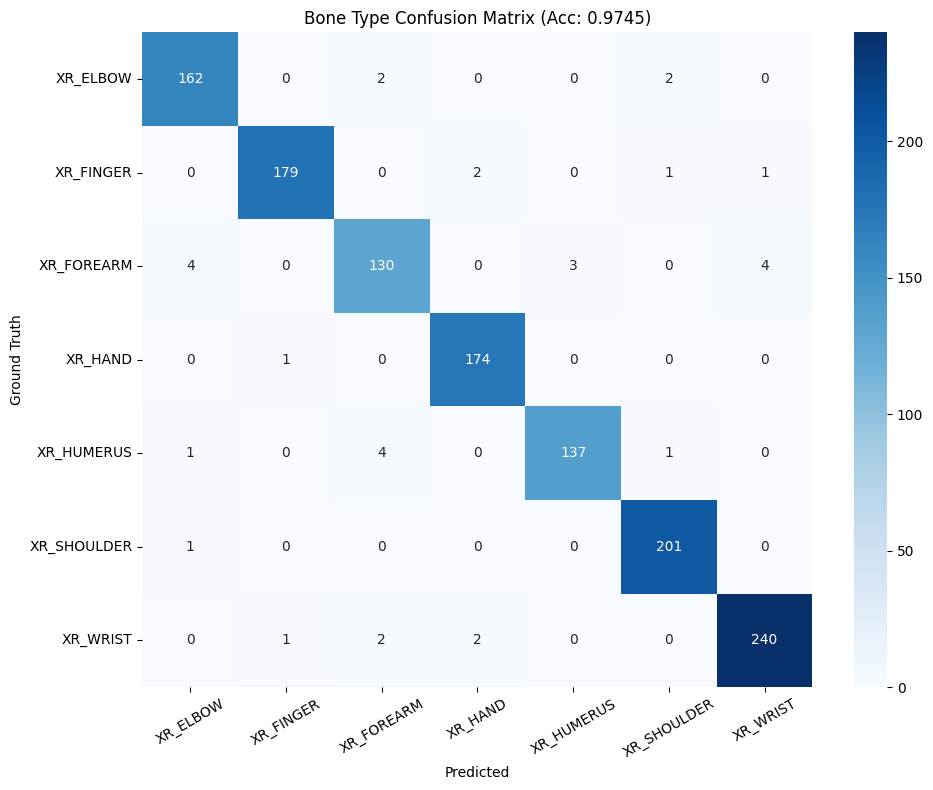


Per-bone accuracy:
  XR_ELBOW: 0.9759  (166 samples)
  XR_FINGER: 0.9781  (183 samples)
  XR_FOREARM: 0.9220  (141 samples)
  XR_HAND: 0.9943  (175 samples)
  XR_HUMERUS: 0.9580  (143 samples)
  XR_SHOULDER: 0.9950  (202 samples)
  XR_WRIST: 0.9796  (245 samples)


In [15]:
all_bone_preds  = np.array(all_bone_preds)
all_bone_labels = np.array(all_bone_labels)

bone_acc = np.mean(all_bone_preds == all_bone_labels)
print(f"Bone type accuracy: {bone_acc:.4f}")

cm_bone = confusion_matrix(all_bone_labels, all_bone_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_bone, annot=True, fmt='d', cmap='Blues', ax=ax,
    xticklabels=BONE_TYPES,
    yticklabels=BONE_TYPES
)
ax.set_title(f'Bone Type Confusion Matrix (Acc: {bone_acc:.4f})')
ax.set_xlabel('Predicted'); ax.set_ylabel('Ground Truth')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout(); plt.show()

print("\nPer-bone accuracy:")
for i, bt in enumerate(BONE_TYPES):
    mask = all_bone_labels == i
    if mask.sum() == 0:
        print(f"  {bt}: no samples")
        continue
    acc = (all_bone_preds[mask] == i).mean()
    print(f"  {bt}: {acc:.4f}  ({mask.sum()} samples)")

## 15. Inference helper — use this in your pipeline

Drop-in function for the full pipeline: given a study folder, returns abnormality score + predicted bone type.

In [16]:
def predict_study(study_dir, model, device, threshold=0.5, max_images=12):
    """
    Run the general fallback model on a study folder.

    Parameters
    ----------
    study_dir : str
        Path to the study folder containing PNG images.
    model : MultiTaskAttentionMIL
        Loaded model in eval mode.
    device : torch.device
    threshold : float
        Decision threshold for abnormality (default 0.5, tune per use case).
    max_images : int
        Max images to load from the study bag.

    Returns
    -------
    dict with keys:
        'abnormal_score'  : float  [0, 1]
        'is_abnormal'     : bool
        'bone_type'       : str    (predicted bone type name)
        'bone_idx'        : int
        'bone_probs'      : list[float]  (softmax over all bone types)
    """
    model.eval()
    images = []

    fnames = sorted([
        f for f in os.listdir(study_dir)
        if f.lower().endswith(".png")
    ])
    if len(fnames) > max_images:
        # Centre-crop the bag
        s = (len(fnames) - max_images) // 2
        fnames = fnames[s:s + max_images]

    for fname in fnames:
        img = preprocess_xray(os.path.join(study_dir, fname))
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        img = val_tf(img)
        images.append(img)

    if len(images) == 0:
        return None

    bags = torch.stack(images).unsqueeze(0).to(device)   # [1, N, 3, 224, 224]

    with torch.no_grad():
        out_abn, out_bone, _ = model(bags)
        abnormal_score = torch.sigmoid(out_abn).item()
        bone_probs     = F.softmax(out_bone, dim=0).cpu().tolist()
        bone_idx       = int(np.argmax(bone_probs))

    return {
        'abnormal_score': abnormal_score,
        'is_abnormal':    abnormal_score >= threshold,
        'bone_type':      BONE_TYPES[bone_idx],
        'bone_idx':       bone_idx,
        'bone_probs':     bone_probs,
    }


# ── Quick sanity check on one valid study ──
sample_row  = valid_ds.df.iloc[0]
parts       = sample_row.study_path.split("/", 2)
sample_base = get_bone_base(parts[0], parts[1])
sample_dir  = os.path.join(sample_base, parts[2])

result = predict_study(sample_dir, model, device)
if result:
    print(f"Study  : {sample_row.study_path}")
    print(f"True   : abnormal={sample_row.abnormal}, bone={BONE_TYPES[sample_row.bone]}")
    print(f"Pred   : abnormal_score={result['abnormal_score']:.4f}, "
          f"is_abnormal={result['is_abnormal']}, bone={result['bone_type']}")

Study  : valid/XR_WRIST/patient11389/study1_negative
True   : abnormal=0, bone=XR_WRIST
Pred   : abnormal_score=0.1604, is_abnormal=False, bone=XR_WRIST


In [ ]:
# ── Final: verify best model saved ──
import os
print("Done! Output files:")
for f in os.listdir("/kaggle/working"):
    fpath = f"/kaggle/working/{f}"
    if os.path.isfile(fpath):
        size_mb = os.path.getsize(fpath) / 1e6
        print(f"  {f}  ({size_mb:.1f} MB)")

from IPython.display import FileLink
# ── Final: verify best model saved ──
import os
import shutil

print("Done! Output files:")
for f in os.listdir("/kaggle/working"):
    fpath = f"/kaggle/working/{f}"
    if os.path.isfile(fpath):
        size_mb = os.path.getsize(fpath) / 1e6
        print(f"  {f}  ({size_mb:.1f} MB)")

# ── Copy checkpoint to /kaggle/working root 
ckpt_src = os.path.join(CHECKPOINT_DIR, "last_checkpoint_general.pth")
if os.path.exists(ckpt_src):
    shutil.copy(ckpt_src, "/kaggle/working/last_checkpoint_general.pth")
    print("Checkpoint copied to output folder.")
else:
    print("No checkpoint found to copy.")

# ── Safety net: force-save best model if it wasn't saved during training ──
if not os.path.exists(BEST_MODEL_PATH):
    torch.save(model.state_dict(), BEST_MODEL_PATH)
    print(f"Forced save → {BEST_MODEL_PATH}")

from IPython.display import FileLink
FileLink('/kaggle/working/best_model_general.pth')  
FileLink('/kaggle/working/best_model_general.pth')